In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_excel('/content/drive/MyDrive/sales-superstore-activation.xlsx')

## 1. Initial Data Exploration

In [4]:
df

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
0,BN-2011-7407039,2011-01-01,Ruby Patel,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,Paper,"Enermax Note Cards, Premium",0.5,45,-26,3,False
1,AZ-2011-9050313,2011-01-03,Summer Hayward,United Kingdom,England,Southport,North,Consumer,Economy,Furniture,Bookcases,"Dania Corner Shelving, Traditional",0.0,854,290,7,True
2,AZ-2011-6674300,2011-01-04,Devin Huddleston,France,Auvergne-Rhône-Alpes,Valence,Central,Consumer,Economy,Office Supplies,Art,"Binney & Smith Sketch Pad, Easy-Erase",0.0,140,21,3,True
3,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Art,"Boston Markers, Easy-Erase",0.5,27,-22,2,True
4,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,Storage,"Eldon Folders, Single Width",0.5,17,-1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8042,AZ-2014-766953,2014-12-31,Jose Gambino,United Kingdom,England,Maidenhead,North,Corporate,Economy,Furniture,Bookcases,"Ikea Stackable Bookrack, Traditional",0.0,245,91,2,True
8043,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Art,"BIC Pencil Sharpener, Fluorescent",0.5,30,-10,2,False
8044,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,Binders,"Avery Binder Covers, Recycled",0.5,23,-6,4,True
8045,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Technology,Machines,"StarTech Phone, Red",0.5,108,-19,3,False


In [5]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Customer Name,0
Country,0
State,0
City,0
Region,0
Segment,0
Ship Mode,0
Category,0


Sebelum melakukan analisis lebih lanjut, langkah awal yang dilakukan adalah mengecek kelengkapan data melalui identifikasi nilai kosong (null value) pada setiap kolom. Hasilnya menunjukkan bahwa tidak ada nilai kosong (null) di seluruh kolom pada dataset ini, yang berarti data ini lengkap, sehingga tidak diperlukan proses imputasi atau pembersihan data terkait nilai kosong

In [6]:
df.dtypes

,0
Order ID,object
Order Date,datetime64[ns]
Customer Name,object
Country,object
State,object
City,object
Region,object
Segment,object
Ship Mode,object
Category,object


Setelah memastikan bahwa dataset tidak memiliki nilai kosong, langkah selanjutnya adalah mengecek tipe data dari setiap kolom. Tipe data yang tepat sangat penting untuk memastikan setiap kolom dapat dianalisis atau dimanipulasi sesuai fungsinya

### a. Statistics

In [7]:
df_summary = df.select_dtypes(include=['number', 'bool']).describe()
df_summary

,Discount,Sales,Profit,Quantity
count,8047.000000,8047.000000,8047.000000,8047.000000
mean,0.110047,291.845657,35.198211,3.772089
std,0.181773,485.212156,178.125844,2.203369
min,0.000000,3.000000,-3060.000000,1.000000
25%,0.000000,48.000000,1.000000,2.000000
50%,0.000000,117.000000,14.000000,3.000000
75%,0.100000,313.000000,47.000000,5.000000
max,0.850000,6517.000000,2476.000000,14.000000


Dataset terdiri dari 8.047 baris data yang semuanya valid (tidak ada nilai kosong) untuk kolom berikut:

1. Discount
Rata-rata diskon adalah 0.11 (11%), menunjukkan bahwa secara umum diskon yang diberikan tidak terlalu besar.

  Standar deviasi cukup tinggi (0.18), menandakan variasi diskon antar transaksi cukup besar.

  Sebanyak 75% data memiliki diskon ≤ 10%, dan 50% (median) bahkan tidak mendapat diskon sama sekali.

  Diskon maksimum mencapai 85%, yang cukup ekstrem dan bisa dianalisis lebih lanjut.

2. Sales
Nilai penjualan rata-rata adalah sekitar 291.85, namun standar deviasi yang besar (485.21) menunjukkan bahwa ada variasi penjualan yang sangat tinggi antar transaksi.

  Penjualan minimum tercatat hanya 3, sementara maksimum mencapai 6.517, menandakan adanya transaksi dengan volume atau harga tinggi.

  50% transaksi menghasilkan penjualan di bawah 117, mengindikasikan distribusi data yang kemungkinan right-skewed (banyak transaksi kecil, sedikit yang besar).

3. Profit
Rata-rata profit per transaksi adalah 35.20, namun nilai minimum profit sangat rendah, yaitu -3.060, menandakan adanya kerugian besar pada beberapa transaksi.

  Profit maksimum adalah 2.476, sementara 50% dari data memiliki profit ≤ 14, menunjukkan bahwa sebagian besar keuntungan berada di kisaran rendah.

  Tingginya standar deviasi (178.13) mendukung adanya fluktuasi besar dalam profit antar transaksi.

4. Quantity
Rata-rata jumlah produk yang terjual per transaksi adalah 3.77 unit, dengan kuartil tengah di angka 3 unit.

  Jumlah minimum adalah 1 unit, dan maksimum 14 unit.

  Sebagian besar transaksi (75%) melibatkan pembelian ≤ 5 unit, menunjukkan kecenderungan transaksi dalam jumlah kecil-menengah.

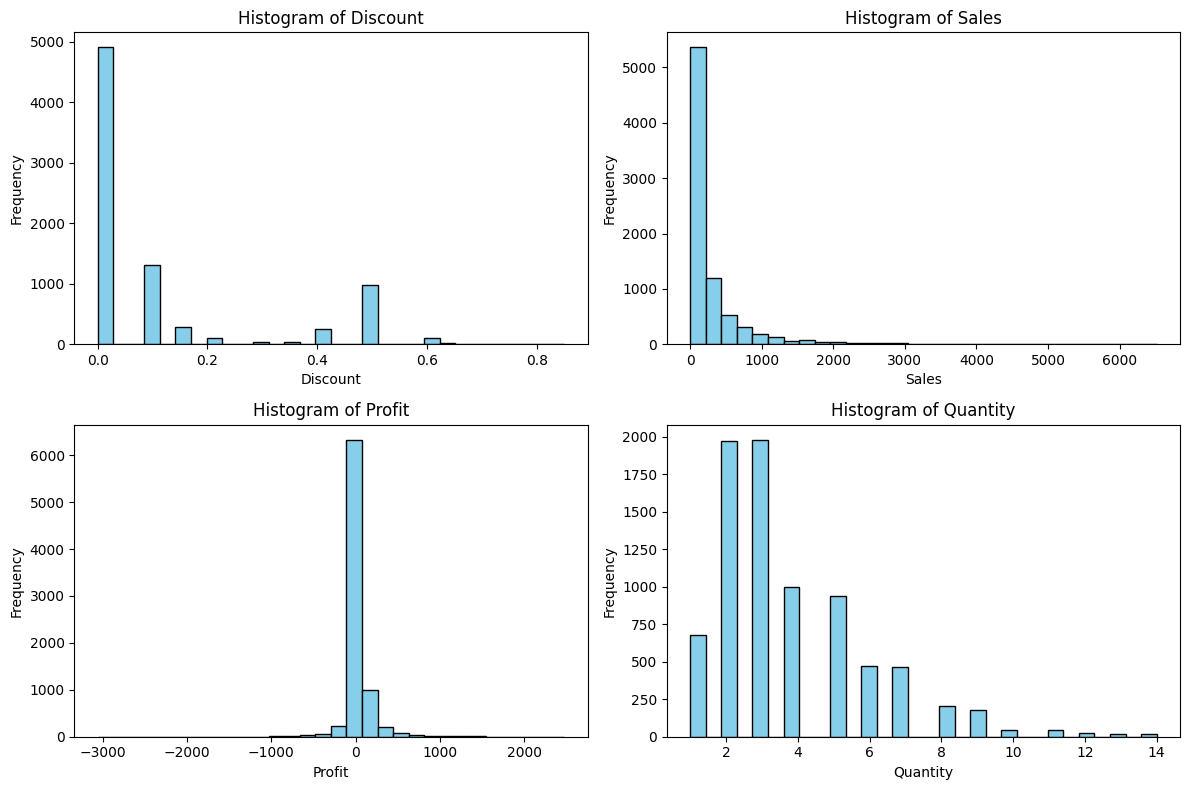

In [8]:
# Kolom numerik yang ingin divisualisasikan
numeric_cols = ['Discount', 'Sales', 'Profit', 'Quantity']

# Ukuran figure keseluruhan
plt.figure(figsize=(12, 8))

# Loop untuk setiap kolom dan buat histogram
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


1. Histogram Diskon

  Histogram ini menunjukkan distribusi nilai diskon yang diterapkan pada produk. Sebagian besar transaksi memiliki diskon sebesar 0, dengan sedikit transaksi lainnya memberikan diskon lebih tinggi. Ini menunjukkan bahwa banyak pelanggan membeli produk tanpa diskon.

2. Histogram Penjualan

  Histogram ini menggambarkan jumlah penjualan per transaksi. Sebagian besar penjualan berada di bawah $1000, dengan beberapa transaksi mencapai angka lebih tinggi hingga $6000. Ini mengindikasikan bahwa sebagian besar pembelian bersifat kecil hingga menengah.

3. Histogram Profit

  Histogram profit menunjukkan distribusi keuntungan dari setiap transaksi. Mayoritas keuntungan berada di sekitar nol, dengan beberapa nilai negatif dan positif yang signifikan, mencerminkan variasi dalam profitabilitas produk atau kategori tertentu.

4. Histogram Kuantitas

  Histogram kuantitas memperlihatkan jumlah unit terjual per transaksi. Kebanyakan transaksi melibatkan pembelian antara 1 hingga 4 unit, sementara pembelian lebih dari itu sangat jarang terjadi.

          Discount     Sales    Profit  Quantity
Discount  1.000000 -0.026350 -0.351328  0.003686
Sales    -0.026350  1.000000  0.441217  0.353441
Profit   -0.351328  0.441217  1.000000  0.098670
Quantity  0.003686  0.353441  0.098670  1.000000


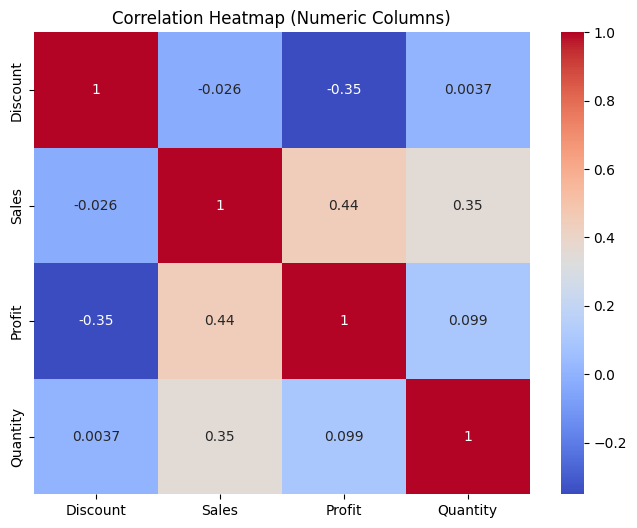

In [9]:
# Define the numeric columns
numeric_cols = ['Discount', 'Sales', 'Profit', 'Quantity']

# Filter the dataframe to include only numeric columns
df_numeric = df[numeric_cols]

# Korelasi antar kolom numerik
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

# Visualisasi heatmap korelasi
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure size
plt.figure(figsize=(8, 6))

# Plot the heatmap using df_numeric.corr() to show correlation for only the selected columns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

# Add a title to the heatmap
plt.title("Correlation Heatmap (Numeric Columns)")

# Show the plot
plt.show()


1. Diskon dan Penjualan:

  Korelasi: -0.026

  Hubungan antara diskon dan penjualan sangat lemah, menunjukkan bahwa perubahan diskon tidak berpengaruh signifikan terhadap jumlah penjualan.

2. Diskon dan Profit:

  Korelasi: -0.35

  Terdapat korelasi negatif sedang antara diskon dan profit, menunjukkan bahwa semakin tinggi diskon yang diberikan, semakin rendah profitabilitas.

3. Penjualan dan Profit:

  Korelasi: 0.44
  
  Ada korelasi positif moderat antara penjualan dan profit, mengindikasikan bahwa peningkatan jumlah penjualan cenderung diikuti oleh peningkatan profit.

4. Penjualan dan Kuantitas:

  Korelasi: 0.35

  Hubungan positif moderat menunjukkan bahwa lebih banyak kuantitas terjual berhubungan dengan peningkatan total penjualan.

5. Profit dan Kuantitas:

  Korelasi: 0.099

  Hubungan ini sangat lemah, menunjukkan bahwa kuantitas terjual tidak memiliki pengaruh signifikan terhadap profitabilitas secara keseluruhan.

6. Kuantitas dan Diskon:

  Korelasi: 0.0037
  
  Ini menunjukkan hampir tidak ada hubungan antara kuantitas produk yang dibeli dengan tingkat diskon yang diterapkan.

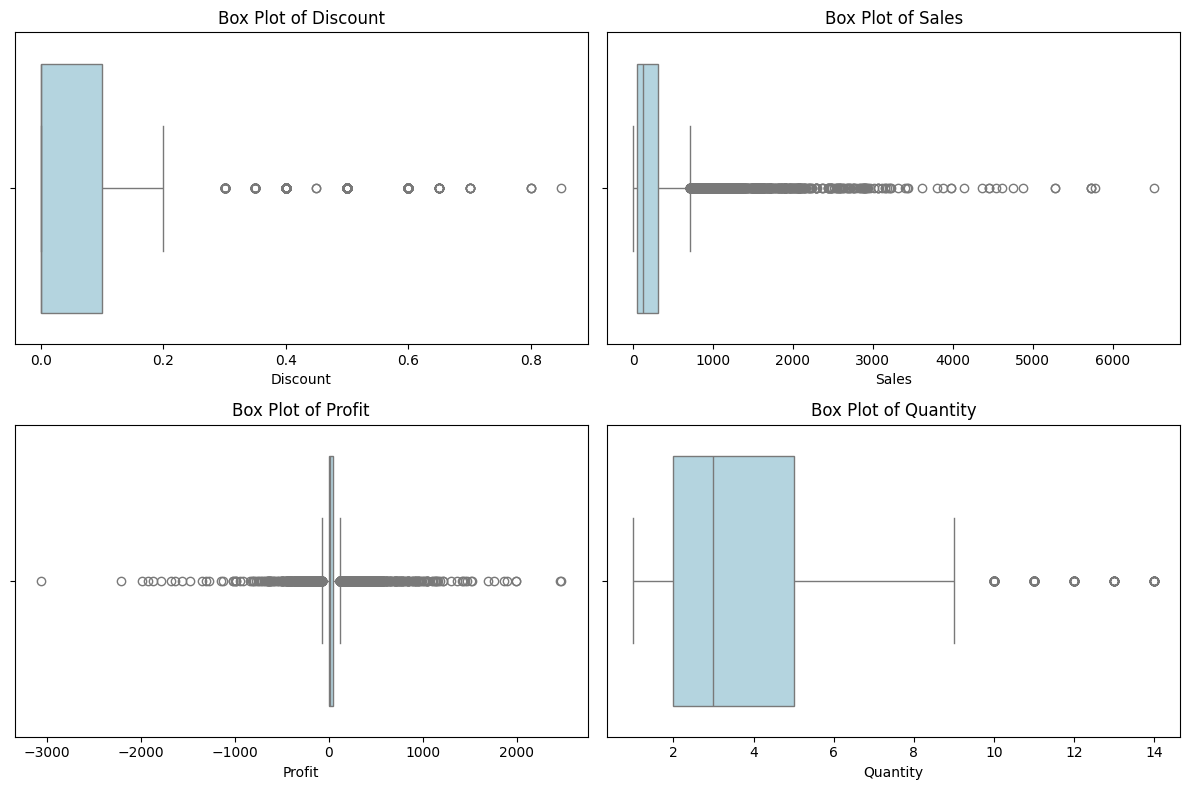

In [10]:
# Define the numeric columns
numeric_cols = ['Discount', 'Sales', 'Profit', 'Quantity']

# Set up the figure size for the plots
plt.figure(figsize=(12, 8))

# Loop through each numeric column and create a box plot
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)  # Create a 2x2 grid of subplots
    sns.boxplot(data=df, x=col, color='lightblue')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the box plots
plt.show()

1. Box Plot Diskon

  Deskripsi: Box plot ini menunjukkan distribusi nilai diskon.

  Interpretasi:
  Median diskon berada di sekitar 0, dengan sebagian besar data terdistribusi di bawah 0.2.

  Terdapat beberapa outlier (titik-titik di luar whiskers) yang menunjukkan adanya transaksi dengan diskon tinggi.

2. Box Plot Penjualan
  Deskripsi: Ini menggambarkan distribusi total penjualan per transaksi.

  Interpretasi:
Median penjualan terlihat lebih tinggi, tetapi ada banyak outlier pada sisi kanan (transaksi dengan nilai sangat tinggi).

  Hal ini menunjukkan bahwa meskipun sebagian besar transaksi memiliki nilai rendah hingga menengah, ada beberapa transaksi besar yang mempengaruhi total penjualan.
3. Box Plot Profit

  Deskripsi: Menunjukkan distribusi profit dari setiap transaksi.

  Interpretasi:
  Median profit berada sedikit di atas nol, tetapi terdapat banyak outlier negatif dan positif.

  Outlier negatif menunjukkan adanya kerugian signifikan pada beberapa transaksi, sementara outlier positif mencerminkan keuntungan luar biasa pada lainnya.

4. Box Plot Kuantitas
  Deskripsi: Menggambarkan jumlah unit terjual per transaksi.

  Interpretasi:
Median kuantitas terjual berkisar antara dua hingga empat unit per transaksi.
Ada sedikit outliers di sisi kanan (transaksi dengan kuantitas sangat tinggi), tetapi secara keseluruhan distribusinya cukup konsisten.

## 2. LRFM

<ipython-input-11-8839170aa5f5>:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=rfm_df, palette='viridis', order=rfm_df['Segment'].value_counts().index)


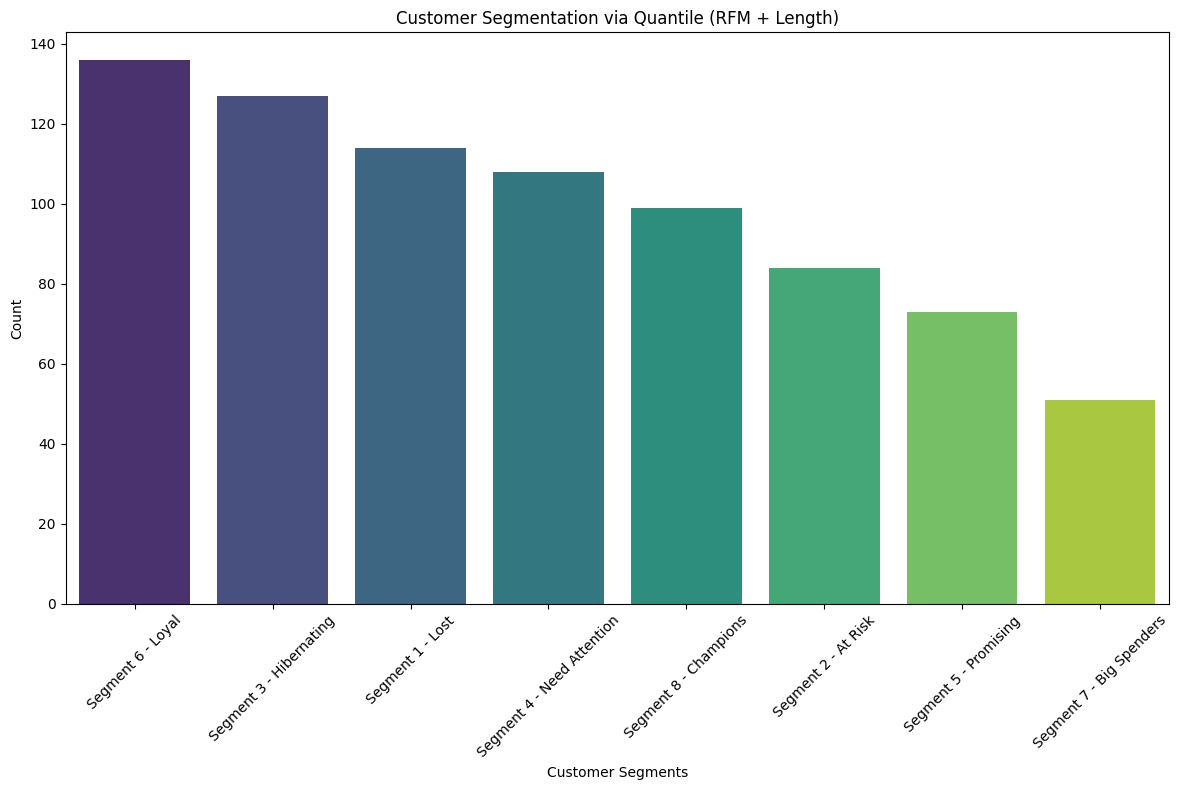

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load your dataset ---
df['Order Date'] = pd.to_datetime(df['Order Date'])

# --- RFM+L Analysis ---

# Snapshot date: 1 hari setelah transaksi terakhir
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

# Recency: Selisih hari dari snapshot date
df['Recency'] = (snapshot_date - df['Order Date']).dt.days

# Frequency: Jumlah order unik per customer
frequency = df.groupby('Customer Name')['Order ID'].nunique()

# Monetary: Total pembelanjaan per customer
monetary = df.groupby('Customer Name')['Sales'].sum()

# Length: Lama waktu antara transaksi pertama dan terakhir per customer
length = df.groupby('Customer Name')['Order Date'].agg(lambda x: (x.max() - x.min()).days)

# Gabungkan semua metrik ke dalam satu DataFrame
rfm_df = pd.DataFrame({
    'Recency': df.groupby('Customer Name')['Recency'].min(),
    'Frequency': frequency,
    'Monetary': monetary,
    'Length': length
})

# --- Skoring menggunakan quantile-based binning (semakin tinggi, semakin baik) ---

# Recency: semakin kecil semakin baik → score 5 terbaik
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency, Monetary, Length: semakin besar semakin baik → score 5 terbaik
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 5, labels=[1, 2, 3, 4, 5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm_df['L_Score'] = pd.qcut(rfm_df['Length'], 5, labels=[1, 2, 3, 4, 5])


# Hitung total RFML score (dalam angka, bukan gabungan string)
rfm_df['RFML_Score_Int'] = (
    rfm_df['R_Score'].astype(int) +
    rfm_df['F_Score'].astype(int) +
    rfm_df['M_Score'].astype(int) +
    rfm_df['L_Score'].astype(int)
)

# Buat segmentasi ke dalam 8 kelompok dengan quantile
rfm_df['Segment'] = pd.qcut(
    rfm_df['RFML_Score_Int'],
    q=8,
    labels=[
        'Segment 1 - Lost',
        'Segment 2 - At Risk',
        'Segment 3 - Hibernating',
        'Segment 4 - Need Attention',
        'Segment 5 - Promising',
        'Segment 6 - Loyal',
        'Segment 7 - Big Spenders',
        'Segment 8 - Champions'
    ]
)
plt.figure(figsize=(12, 8))
sns.countplot(x='Segment', data=rfm_df, palette='viridis', order=rfm_df['Segment'].value_counts().index)
plt.title("Customer Segmentation via Quantile (RFM + Length)")
plt.xlabel("Customer Segments")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [12]:
top_5_customers = rfm_df.sort_values(by='RFML_Score_Int', ascending=False).head(5)
top_5_customers

,Recency,Frequency,Monetary,Length,R_Score,F_Score,M_Score,L_Score,RFML_Score_Int,Segment
Customer Name,,,,,,,,,,
Kayla Tearle,24,12,6637,1358,5,5,5,5,20,Segment 8 - Champions
Lara Stoate,3,8,6732,1426,5,5,5,5,20,Segment 8 - Champions
Peter Daly,8,10,7804,1288,5,5,5,5,20,Segment 8 - Champions
Philip Newsom,23,10,10893,1315,5,5,5,5,20,Segment 8 - Champions
Evie Flockhart,17,9,4526,1434,5,5,5,5,20,Segment 8 - Champions


In [13]:
top_5_spenders = rfm_df.sort_values(by='Monetary', ascending=False).head(5)
top_5_spenders = top_5_spenders.sort_values(by='Monetary', ascending=False)
top_5_spenders

,Recency,Frequency,Monetary,Length,R_Score,F_Score,M_Score,L_Score,RFML_Score_Int,Segment
Customer Name,,,,,,,,,,
Angie Massengill,307,10,16146,841,2,5,5,2,14,Segment 6 - Loyal
Lola Hughes,19,9,13191,1249,5,5,5,5,20,Segment 8 - Champions
Ashton Charles,64,10,13056,1328,4,5,5,5,19,Segment 8 - Champions
Isaac David,7,10,11271,1210,5,5,5,4,19,Segment 8 - Champions
Philip Newsom,23,10,10893,1315,5,5,5,5,20,Segment 8 - Champions


In [14]:
# Combine the RFML results with the original dataframe (df)
df = pd.merge(df, rfm_df, left_on='Customer Name', right_index=True, how='left')

df


,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment_x,Ship Mode,Category,...,Recency_y,Frequency,Monetary,Length,R_Score,F_Score,M_Score,L_Score,RFML_Score_Int,Segment_y
0,BN-2011-7407039,2011-01-01,Ruby Patel,Sweden,Stockholm,Stockholm,North,Home Office,Economy Plus,Office Supplies,...,479,5,690,982,1,2,1,3,7,Segment 2 - At Risk
1,AZ-2011-9050313,2011-01-03,Summer Hayward,United Kingdom,England,Southport,North,Consumer,Economy,Furniture,...,191,7,6120,1268,2,4,5,5,16,Segment 7 - Big Spenders
2,AZ-2011-6674300,2011-01-04,Devin Huddleston,France,Auvergne-Rhône-Alpes,Valence,Central,Consumer,Economy,Office Supplies,...,132,6,1435,1326,3,3,2,5,13,Segment 5 - Promising
3,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,...,66,8,3599,1392,4,5,4,5,18,Segment 8 - Champions
4,BN-2011-2819714,2011-01-04,Mary Parker,United Kingdom,England,Birmingham,North,Corporate,Economy,Office Supplies,...,66,8,3599,1392,4,5,4,5,18,Segment 8 - Champions
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8042,AZ-2014-766953,2014-12-31,Jose Gambino,United Kingdom,England,Maidenhead,North,Corporate,Economy,Furniture,...,1,13,6824,836,5,5,5,2,17,Segment 8 - Champions
8043,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,...,1,5,4359,1178,5,2,4,4,15,Segment 6 - Loyal
8044,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Office Supplies,...,1,5,4359,1178,5,2,4,4,15,Segment 6 - Loyal
8045,BN-2014-4140795,2014-12-31,Daniel Hamilton,Netherlands,North Brabant,Eindhoven,Central,Home Office,Economy Plus,Technology,...,1,5,4359,1178,5,2,4,4,15,Segment 6 - Loyal


In [15]:
# Export the DataFrame to an Excel file
df.to_excel('sales_data_with_rfm.xlsx', index=False)  # index=False prevents writing row indices to the file
# Download the file (Google Colab)
from google.colab import files
files.download('sales_data_with_rfm.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from google.oauth2 import service_account
import pandas_gbq
import seaborn as sns
import pandas as pd

superstore_data = pd.read_excel('sales_data_with_rfm.xlsx')
project_id = 'the-discipline-453502-j6'
dataset_id = 'superstore_data'
table_name = 'store_data'
key_path = '/Users/revanfahrezi/Downloads/BigQuery/the-discipline-453502-j6-438f793fa942.json'
scopes = ['https://www.googleapis.com/auth/bigquery']
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

pandas_gbq.to_gbq(superstore_data,
                  f'{dataset_id}.{table_name}',
                  project_id=project_id,
                  if_exists='replace',
                  credentials=credentials
)

In [ ]:
sql_query = f'SELECT * FROM {project_id}.{dataset_id}.{table_name} LIMIT 10'

df = pandas_gbq.read_gbq(sql_query, project_id=project_id, credentials=credentials)

## 3. Kesimpulan

# Kesimpulan dan Rekomendasi Segmentasi Pelanggan

## Kesimpulan

1. **Overview**
   - Segmentasi pelanggan dibagi menjadi beberapa kategori: Lost, At Risk, Hibernating, Need Attention, Promising, Loyal, Big Spender, dan Champions.
   - Setiap segmen menunjukkan karakteristik penjualan dan profit yang berbeda.

2. **Lost**
   - Pelanggan dalam segmen ini mengalami penurunan dalam frekuensi pembelian.
   - Penjualan tertinggi berasal dari Inggris dan Île-de-France.

3. **At Risk**
   - Pelanggan di segmen ini berpotensi untuk berhenti melakukan pembelian jika tidak ada intervensi yang tepat.
   - Inggris tetap menjadi pasar utama dengan tingkat risiko tinggi.

4. **Hibernating**
   - Pelanggan pada segmen ini jarang melakukan pembelian tetapi masih aktif secara sporadis.
   - Fokus utama pada produk seperti Copiers dan Phones.

5. **Need Attention**
   - Segmen ini memerlukan perhatian khusus untuk mencegah kehilangan pelanggan lebih lanjut.
   - Produk Storage dan Copiers mendominasi penjualan di segmen ini.

6. **Promising**
   - Pelanggan di sini menunjukkan potensi pertumbuhan yang baik.
   - Lower Saxony menonjol sebagai wilayah dengan peningkatan aktivitas belanja.

7. **Loyal**
   - Segmen ini terdiri dari pelanggan setia yang memberikan kontribusi signifikan terhadap pendapatan perusahaan.
   - Produk-produk seperti Diabolos dan Appliances sangat populer di kalangan mereka.

8. **Big Spender**
   - Pelanggan dalam kategori ini mengeluarkan jumlah uang yang besar untuk produk tertentu seperti Phones dan Machines.
   - England merupakan pasar utama bagi big spenders.

9. **Champions**
   - Ini adalah segmen terbaik dengan kontribusi terbesar terhadap pendapatan perusahaan secara keseluruhan.
   - England kembali menjadi wilayah dominan dalam hal penjualan.

## Rekomendasi

1. **Lost**:
   - Lakukan kampanye re-engagement untuk menarik kembali minat mereka melalui diskon atau promosi khusus pada produk favorit sebelumnya (Copiers).

2. **At Risk**:
   - Implementasikan program loyalitas atau insentif guna mendorong pembelian ulang sebelum mereka benar-benar berhenti bertransaksi dengan perusahaan Anda.

3. **Hibernating**:
   - Kirimkan pengingat berkala mengenai produk baru atau layanan tambahan yang mungkin menarik bagi mereka berdasarkan riwayat belanja sebelumnya (Phones).

4. **Need Attention**:
   - Berikan dukungan personalisasi lebih lanjut serta tawarkan solusi cepat atas masalah apapun agar meningkatkan kepuasan konsumen sehingga dapat mempertahankan hubungan jangka panjang bersama merek Anda.

5. **Promising**:
   - Fokuskan upaya pemasaran kepada kelompok demografis serupa guna memperluas basis konsumen potensial lainnya.

6. **Program Loyalitas & Sistem Penghargaan Untuk Pelanggan Setia**:
   - Berikan penghargaan eksklusif maupun akses prioritas ke acara-acara spesial sebagai bentuk apresiasi atas kesetiaan para pelanggan setia tersebut.

7. **Big Spenders**:
   - Tawarkan paket premium ataupun layanan VIP guna meningkatkan pengalaman belanja serta menjaga hubungan baik antara kedua belah pihak.

8. **Champions**:
   - Libatkan para champions ke dalam proses pengembangan produk co-creation agar mendapatkan wawasan berharga langsung dari perspektif pengguna akhir sekaligus membangun rasa kepemilikan terhadap merek itu sendiri.

  Dengan penerapan strategi-strategi tersebut, diharapkan dapat meningkatkan tingkat keterlibatan sekaligus memperkuat posisi kompetitif bisnis Anda di pasar global saat ini maupun di masa depan.
